# PlantMetWiki figures

Publication-quality figures for the PlantMetWiki paper.

---

## How to run

**Step 1 — generate data from Virtuoso** (run once per data version, ~30 sec):
```bash
conda activate plantmetwiki-rdf

# Make sure Virtuoso is running
# (cd to Snorql-UI: docker compose up -d virtuoso)

# Query Virtuoso and write CSVs to notebooks/figures/output/
python scripts/generate_figures_data.py

# Skip slow per-species query for quick iteration
python scripts/generate_figures_data.py --skip-species
```

**Step 2 — run this notebook** (loads CSVs, produces figures):
```
Kernel → Restart & Run All
```

Figures are saved to **`figures/output/figures/`** as `.pdf` and `.svg`.

---

## Architecture

```
Virtuoso (graph/pathways + graph/gpml-taxonomy-extra + graph/ncbitaxon)
    │
    ▼  scripts/generate_figures_data.py   (queries via SPARQLWrapper)
notebooks/figures/output/*.csv            ← committed to git
    │
    ▼  this notebook
notebooks/figures/output/figures/*.pdf/.svg
```

The CSVs are committed to git so **this notebook runs without Virtuoso**.
Only re-run `generate_figures_data.py` when the underlying data changes.

---

## Named graphs queried

| CSV | Graph(s) |
|---|---|
| `genes/metabolites/enzymes/conversions_per_pathway.csv` | `graph/pathways` |
| `interaction_types.csv` | `graph/pathways` |
| `pathway_titles.csv` | `graph/pathways` |
| `species_per_pathway.csv` | `graph/pathways` + `graph/gpml-taxonomy-extra` |
| `per_species_nrs.csv` | all three + `graph/ncbitaxon` (species labels) |

**Kernel:** `plantmetwiki-rdf`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT_DIR  = Path('figures/output')
FIG_DIR  = OUT_DIR / 'figures'   # PDF/SVG outputs go here
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'font.family': 'sans-serif',
                     'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans']})

# ── Load pre-computed CSVs ────────────────────────────────────────────────────
def load(name):
    path = OUT_DIR / name
    assert path.exists(), f'Missing: {path}\nRun: python scripts/generate_figures_data.py'
    return pd.read_csv(path)

def save_fig(fig, name):
    for ext in ('pdf', 'svg'):
        fig.savefig(FIG_DIR / f'{name}.{ext}', bbox_inches='tight')
    print(f'  Saved → {FIG_DIR}/{name}.{{pdf,svg}}')

WP_INTERACTION = 'http://vocabularies.wikipathways.org/wp#Interaction'

print('Loading CSVs ...')
genes       = load('genes_per_pathway.csv')
metabolites = load('metabolites_per_pathway.csv')
enzymes     = load('enzymes_per_pathway.csv')
conversions = load('conversions_per_pathway.csv')
int_types   = load('interaction_types.csv')
per_species = load('per_species_nrs.csv')
species_pw  = load('species_per_pathway.csv')
titles      = load('pathway_titles.csv')
ann         = load('annotation_summary.csv').set_index('entity')
print(f'  pathways: {len(titles):,}  |  genes: {len(genes):,}  |  species: {len(per_species):,}')
print(f'  Figures will be saved to: {FIG_DIR.resolve()}')

Loading CSVs ...
  pathways: 2,478  |  genes: 1,484  |  species: 417
  Figures will be saved to: /Users/elenadelpup/Library/CloudStorage/OneDrive-WageningenUniversity&Research/PhD/software/plantwiki/gpml-to-rdf/notebooks/figures/output/figures


---
## 2. Normalize

In [2]:
def norm(df, count_col, count_name):
    df = df.copy()
    df = df.rename(columns={count_col: count_name})
    df[count_name] = pd.to_numeric(df[count_name], errors="coerce").fillna(0)
    if "pwID" in df.columns:
        df["pwID"] = df["pwID"].astype(str)
    return df

genes       = norm(genes,       "count", "genes")
metabolites = norm(metabolites, "count", "metabolites")
enzymes     = norm(enzymes,     "count", "enzymes")
conversions = norm(conversions, "count", "conversions")
species_pw  = norm(species_pw,  "count", "species")

int_types["n"] = pd.to_numeric(int_types["n"], errors="coerce").fillna(0).astype(int)
WP_INTERACTION = "http://vocabularies.wikipathways.org/wp#Interaction"
total_interactions = int(int_types.loc[int_types["type"] == WP_INTERACTION, "n"].iloc[0])

print("✅ Data ready")
print(f"  Pathways with gene data:       {len(genes):,}")
print(f"  Pathways with metabolite data: {len(metabolites):,}")
print(f"  Total interactions:            {total_interactions:,}")
print(f"  Species in per-species table:  {len(per_species):,}")

✅ Data ready
  Pathways with gene data:       1,484
  Pathways with metabolite data: 2,462
  Total interactions:            54,800
  Species in per-species table:  417


---
## 3. Figure: Overview bar chart (log scale)

### How pathway and reaction counts are calculated

PlantMetWiki contains two types of GPML-derived objects loaded together into `graph/pathways`:

| Type | IRI pattern | Count |
|------|-------------|-------|
| **Multispecies plant pathways** | `.../pathways/PC*` | 1,162 |
| **Individual enzymatic reactions** | `.../pathways/RC*` | 1,316 |

Both are typed as `wp:Pathway` in the WikiPathways RDF model (the `gpml2rdf` Java converter assigns `wp:Pathway` to any GPML file, whether it is a multi-step pathway or a single reaction). They are distinguished only by their IRI prefix (`PC` vs `RC`), which we filter on in `pathway_titles.csv`.

### What was wrong in the previous calculation

The overview bar previously used `len(genes_per_pathway.csv)` = **1,484** as the pathway count. That CSV is generated by a query that counts pathways containing **at least one gene product** — it therefore excludes pathways with only metabolites or interactions (undercounting), and it includes both PC* *and* RC* entries (mixing pathways with reactions). The corrected figure uses `pathway_titles.csv` filtered by IRI prefix, giving the exact **1,162 pathways** and **1,316 reactions** that match the input GPML files.


  Saved → figures/output/figures/plantmetwiki_overview_barlog.{pdf,svg}


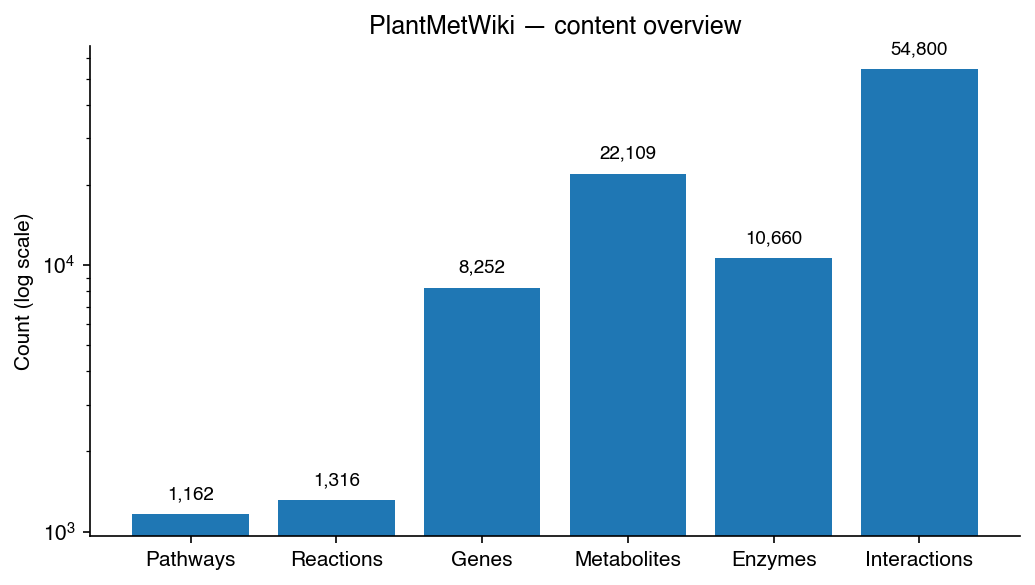

In [3]:
n_pathways  = titles[titles['pwID'].str.contains('/PC')]['pwID'].nunique()
n_reactions = titles[titles['pwID'].str.contains('/RC')]['pwID'].nunique()

overview = {
    "Pathways":     n_pathways,
    "Reactions":    n_reactions,
    "Genes":        int(genes["genes"].sum()),
    "Metabolites":  int(metabolites["metabolites"].sum()),
    "Enzymes":      int(enzymes["enzymes"].sum()),
    "Interactions": total_interactions,
}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(overview.keys()), list(overview.values()))
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('PlantMetWiki — content overview')
for bar, val in zip(bars, overview.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.1,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'plantmetwiki_overview_barlog')
plt.show()


### Interpretation

This log-scale overview shows the size of PlantMetWiki across its five main content types.
The 1,162 **pathways** (PC\* IRIs) are curated multi-step metabolic maps; the 1,316 **reactions** (RC\* IRIs) are individual enzymatic steps — both are typed `wp:Pathway` by the `gpml2rdf` converter, so they are distinguished only by IRI prefix.
**Genes** and **Enzymes** are counted as distinct DataNode instances across all pathways (a gene appearing in five pathways is counted once per pathway in `genes_per_pathway.csv`, but here they are raw per-pathway sums; see Figure 3b for distinct-node counts).
**Metabolites** are the chemical compound nodes; **Interactions** are the typed edges (catalysis, conversion, binding, etc.).
The log scale is required because counts span 3–4 orders of magnitude.


> **Figure caption — Overview bar chart.**
> Total counts of the five main content types in PlantMetWiki, plotted on a logarithmic scale.
> **Pathways** (`wp:Pathway`, IRI prefix `…/pathways/PC*`) and **reactions** (`wp:Pathway`, IRI prefix `…/pathways/RC*`) are both typed `wp:Pathway` by the `gpml2rdf` converter and are distinguished only by their IRI prefix.
> **Genes** (`wp:GeneProduct`), **enzymes** (`wp:Protein`), and **metabolites** (`wp:Metabolite`) are DataNode entity types from the WikiPathways vocabulary (`http://vocabularies.wikipathways.org/wp#`).
> **Interactions** counts all instances of `wp:Interaction` (the parent class covering all typed edges).
> Genes and enzymes are summed across pathway memberships via `dcterms:isPartOf`; a node shared across *n* pathways contributes *n* to the total.


---
## 3b. Figure: Overview with species-annotation coverage

A variant of Figure 3 showing, for each entity type, how many nodes carry a **direct** `wp:organism` species annotation.
Direct annotations exist only on gene product and protein (enzyme) nodes, derived from the PlantCyc `proteins.dat` SPECIES field.
Metabolites are species-neutral in PlantCyc — their species context is inferred indirectly via shared-pathway co-occurrence (see Figures 6b and 7).


  Saved → figures/output/figures/plantmetwiki_overview_annotated.{pdf,svg}


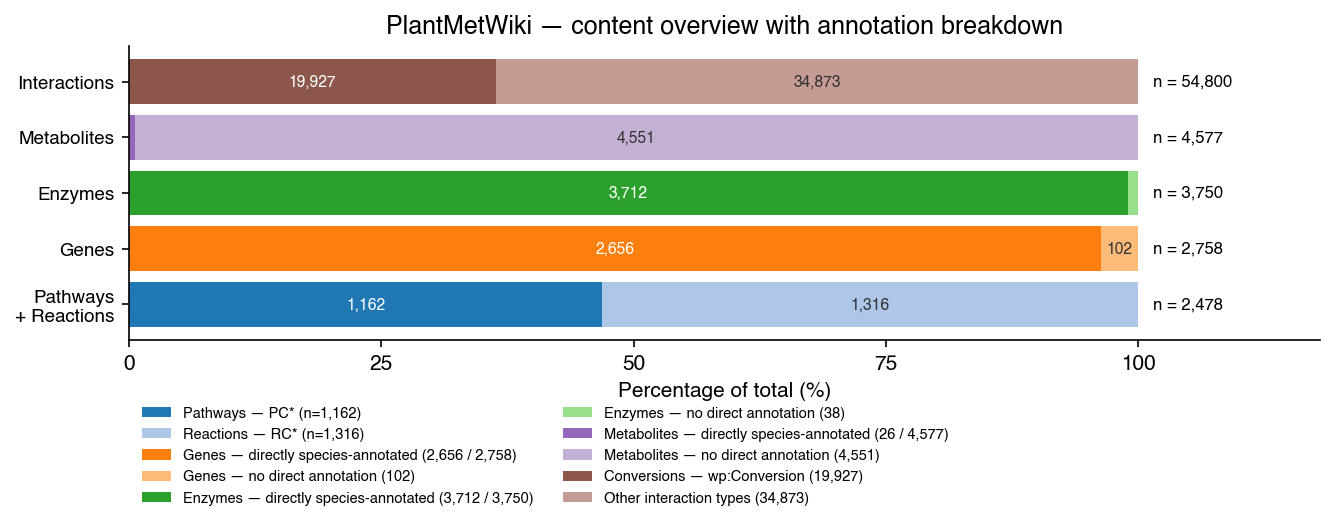

In [4]:
from matplotlib.patches import Patch

WP_CONVERSION  = 'http://vocabularies.wikipathways.org/wp#Conversion'
WP_INTERACTION = 'http://vocabularies.wikipathways.org/wp#Interaction'

n_pathways  = titles[titles['pwID'].str.contains('/PC')]['pwID'].nunique()
n_reactions = titles[titles['pwID'].str.contains('/RC')]['pwID'].nunique()

g_ann = int(ann.loc['genes',       'annotated']); g_tot = int(ann.loc['genes',       'total'])
e_ann = int(ann.loc['enzymes',     'annotated']); e_tot = int(ann.loc['enzymes',     'total'])
m_ann = int(ann.loc['metabolites', 'annotated']); m_tot = int(ann.loc['metabolites', 'total'])

n_conv    = int(int_types.loc[int_types['type'] == WP_CONVERSION,  'n'].values[0])
n_tot_int = int(int_types.loc[int_types['type'] == WP_INTERACTION, 'n'].values[0])
n_other   = n_tot_int - n_conv

# category labels, primary (left) and secondary (right) absolute counts
cats    = ['Pathways\n+ Reactions', 'Genes', 'Enzymes', 'Metabolites', 'Interactions']
primary = [n_pathways,  g_ann,          e_ann,          m_ann,  n_conv ]
secondr = [n_reactions, g_tot - g_ann,  e_tot - e_ann,  m_tot - m_ann,  n_other]
totals  = [p + s for p, s in zip(primary, secondr)]

# Normalize to 100 %
pct_p = [p / t * 100 for p, t in zip(primary, totals)]
pct_s = [s / t * 100 for s, t in zip(secondr, totals)]

C_PRI = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
C_SEC = ['#aec7e8', '#ffbb78', '#98df8a', '#c5b0d5', '#c49c94']

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(cats))

ax.barh(y, pct_p, color=C_PRI)
ax.barh(y, pct_s, left=pct_p, color=C_SEC)

# Annotate each segment with absolute count (skip if segment < 1 %)
for yi, (p, s, t, pp, ps) in enumerate(zip(primary, secondr, totals, pct_p, pct_s)):
    if pp >= 3:
        ax.text(pp / 2, yi, f'{p:,}', ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')
    if ps >= 3:
        ax.text(pp + ps / 2, yi, f'{s:,}', ha='center', va='center',
                fontsize=7.5, color='#333')
    # Total on right
    ax.text(101.5, yi, f'n = {t:,}', va='center', fontsize=8)

ax.set_xlim(0, 118)
ax.set_xlabel('Percentage of total (%)')
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=9)
ax.set_title('PlantMetWiki — content overview with annotation breakdown')

legend_handles = [
    Patch(facecolor='#1f77b4', label=f'Pathways — PC* (n={n_pathways:,})'),
    Patch(facecolor='#aec7e8', label=f'Reactions — RC* (n={n_reactions:,})'),
    Patch(facecolor='#ff7f0e', label=f'Genes — directly species-annotated ({g_ann:,} / {g_tot:,})'),
    Patch(facecolor='#ffbb78', label=f'Genes — no direct annotation ({g_tot-g_ann:,})'),
    Patch(facecolor='#2ca02c', label=f'Enzymes — directly species-annotated ({e_ann:,} / {e_tot:,})'),
    Patch(facecolor='#98df8a', label=f'Enzymes — no direct annotation ({e_tot-e_ann:,})'),
    Patch(facecolor='#9467bd', label=f'Metabolites — directly species-annotated ({m_ann:,} / {m_tot:,})'),
    Patch(facecolor='#c5b0d5', label=f'Metabolites — no direct annotation ({m_tot-m_ann:,})'),
    Patch(facecolor='#8c564b', label=f'Conversions — wp:Conversion ({n_conv:,})'),
    Patch(facecolor='#c49c94', label=f'Other interaction types ({n_other:,})'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=False, fontsize=7,
          ncol=2, bbox_to_anchor=(0, -0.18))

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.42)
save_fig(fig, 'plantmetwiki_overview_annotated')
plt.show()


### Interpretation

For **genes** (2,758 total), 2,656 nodes (96 %) carry a direct `wp:organism` triple — the dark-orange segment.
The remaining ~4 % are gene nodes where PlantCyc did not record a resolvable species, or where the GPML annotation could not be mapped to an NCBITaxon IRI.

For **enzymes** (3,750 total), 3,712 nodes (99 %) are directly annotated — the compact light-green top segment is barely visible.

**Metabolites** (4,577 total) show a fully solid bar because there is no direct species annotation for compounds in the PlantCyc data model.
All metabolite–species associations in PlantMetWiki are therefore *indirect*: a metabolite is attributed to a species only when a gene of that species co-occurs in the same pathway (see Figures 6b and 7).

The stacked bar for Pathways+Reactions uses the same logic as Figure 3: the total bar height is 1,162 + 1,316 = 2,478 objects, split by IRI prefix.


> **Figure caption — Annotation coverage overview.**
> Proportional breakdown (100 % per row) of each entity type by direct species-annotation status.
> Direct annotation: the entity carries a `wp:organism` triple in `graph/gpml-taxonomy-extra`, pointing to an NCBITaxon IRI (`http://purl.obolibrary.org/obo/NCBITaxon_*`).
> Dark colours = directly annotated; light colours = no direct `wp:organism` triple.
> **Genes** (`wp:GeneProduct`): 2,656 / 2,758 annotated (96 %).
> **Enzymes** (`wp:Protein`): 3,712 / 3,750 annotated (99 %).
> **Metabolites** (`wp:Metabolite`): only 26 / 4,577 carry a direct `wp:organism`; the rest are species-neutral in the source PlantCyc data.
> **Interactions**: split into `wp:Conversion` (biochemical reactions, brown) and all other `wp:` sub-types (light brown).


---
## 4. Figure: Cumulative coverage curves

  Saved → figures/output/figures/plantmetwiki_cumulative_coverage.{pdf,svg}


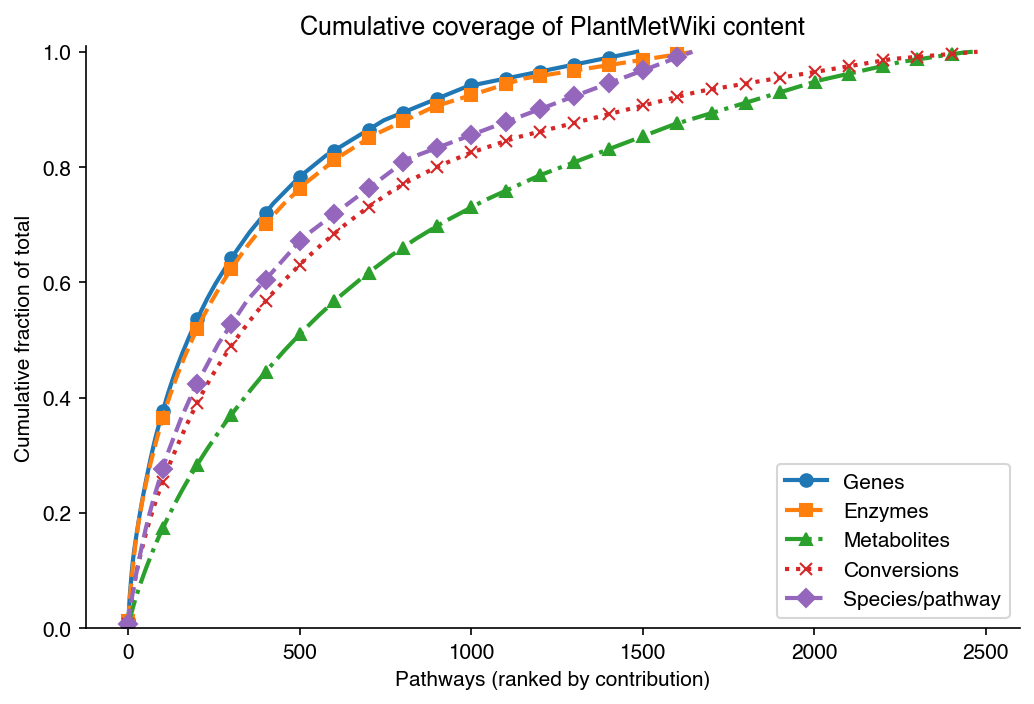

In [5]:
def cumulative_curve(df, col):
    s = df[col].sort_values(ascending=False)
    total = s.sum()
    return (s.cumsum()/total).values if total > 0 else s.cumsum().values

curves = {
    "Genes":           cumulative_curve(genes, "genes"),
    "Enzymes":         cumulative_curve(enzymes, "enzymes"),
    "Metabolites":     cumulative_curve(metabolites, "metabolites"),
    "Conversions":     cumulative_curve(conversions, "conversions"),
    "Species/pathway": cumulative_curve(species_pw, "species"),
}
styles = {
    "Genes":           dict(linestyle="-",  marker="o", markevery=100),
    "Enzymes":         dict(linestyle="--", marker="s", markevery=100),
    "Metabolites":     dict(linestyle="-.", marker="^", markevery=100),
    "Conversions":     dict(linestyle=":",  marker="x", markevery=100),
    "Species/pathway": dict(linestyle="--", marker="D", markevery=100),
}
fig, ax = plt.subplots(figsize=(7, 4.8))
for label, curve in curves.items():
    ax.plot(range(1, len(curve)+1), curve, label=label, linewidth=2, **styles[label])
ax.set_xlabel("Pathways (ranked by contribution)")
ax.set_ylabel("Cumulative fraction of total")
ax.set_ylim(0, 1.01)
ax.set_title("Cumulative coverage of PlantMetWiki content")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save_fig(fig, "plantmetwiki_cumulative_coverage")
plt.show()

### Interpretation

Each curve shows the fraction of the total (for that metric) that is covered when pathways are ranked by their individual count from largest to smallest.
A steep initial rise means that a small number of large pathways dominate; a slow rise means the metric is spread evenly.

**Genes and Enzymes** rise steeply because *Arabidopsis thaliana* pathways — which are the most densely annotated — cluster at the top of the ranking.
**Metabolites and Conversions** also rise steeply because the largest metabolic superpathways are multi-step and compound-rich.
**Species/pathway** plateaus later because species diversity is distributed across many medium-sized pathways rather than concentrated in a few.

This figure is useful for estimating how much of the resource's content can be captured by focusing on the most comprehensive pathways.


> **Figure caption — Cumulative coverage curves.**
> For each metric, pathways are ranked by count (highest first) and the cumulative fraction of the dataset total is plotted against pathway rank.
> Pathway membership is encoded via `dcterms:isPartOf`; entity types are `wp:GeneProduct`, `wp:Protein`, `wp:Metabolite`, `wp:Conversion`, and `wp:organism` (species, `NCBITaxon_*`).
> A steep initial rise indicates concentration in a small number of large pathways.
> Genes and enzymes rise steeply because *Arabidopsis thaliana* (NCBITaxon\_3702) pathways dominate the top ranks.
> The species-per-pathway curve rises more slowly, reflecting that taxonomic diversity is distributed across many medium-sized pathways.


---
## 5. Figure: Interaction types (2-panel)

  Saved → figures/output/figures/plantmetwiki_interaction_types.{pdf,svg}


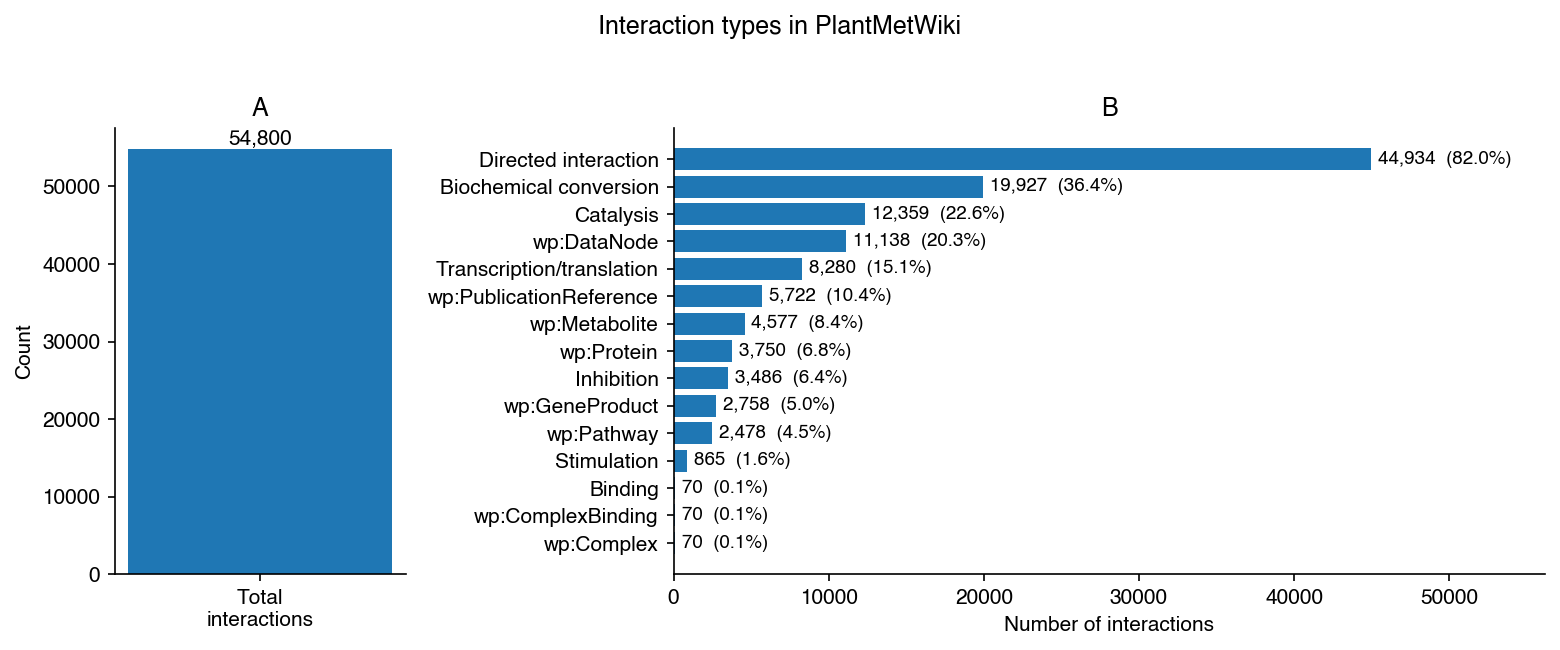

In [6]:
label_map = {
    "http://vocabularies.wikipathways.org/wp#DirectedInteraction":      "Directed interaction",
    "http://vocabularies.wikipathways.org/wp#Conversion":               "Biochemical conversion",
    "http://vocabularies.wikipathways.org/wp#Catalysis":                "Catalysis",
    "http://vocabularies.wikipathways.org/wp#TranscriptionTranslation": "Transcription/translation",
    "http://vocabularies.wikipathways.org/wp#Inhibition":               "Inhibition",
    "http://vocabularies.wikipathways.org/wp#Stimulation":              "Stimulation",
    "http://vocabularies.wikipathways.org/wp#Binding":                  "Binding",
}
sub = int_types[int_types["type"] != WP_INTERACTION].copy()
sub["label"] = sub["type"].map(label_map).fillna(
    sub["type"].str.replace("http://vocabularies.wikipathways.org/wp#", "wp:", regex=False)
)
sub["pct"]   = 100 * sub["n"] / total_interactions
sub = sub.sort_values("n", ascending=True)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 4.2),
                                gridspec_kw={"width_ratios": [1, 3]})
ax0.bar(["Total\ninteractions"], [total_interactions])
ax0.set_ylabel("Count"); ax0.set_title("A")
ax0.text(0, total_interactions, f"{total_interactions:,}",
         ha="center", va="bottom", fontsize=10)
ax0.spines[["top","right"]].set_visible(False)

ax1.barh(sub["label"], sub["n"])
ax1.set_xlabel("Number of interactions"); ax1.set_title("B")
xmax = sub["n"].max()
for y, (n, pct) in enumerate(zip(sub["n"], sub["pct"])):
    ax1.text(n+xmax*0.01, y, f"{n:,}  ({pct:.1f}%)", va="center", fontsize=9)
ax1.set_xlim(0, xmax*1.25)
ax1.spines[["top","right"]].set_visible(False)

fig.suptitle("Interaction types in PlantMetWiki", y=1.02)
plt.tight_layout()
save_fig(fig, "plantmetwiki_interaction_types")
plt.show()

### Interpretation

The WikiPathways vocabulary (`wp:`) defines a type hierarchy for interactions.
Each edge in a pathway diagram is typed with one or more `wp:` classes.

| Type | What it represents |
|------|-------------------|
| **`wp:Interaction`** | Parent class — every interaction is an `Interaction`; count = total edges |
| **`wp:DirectedInteraction`** | A directed edge without further specification (e.g. transport, flow) |
| **`wp:Conversion`** | A biochemical transformation: substrate(s) → product(s). The core of metabolic pathways |
| **`wp:Catalysis`** | An enzyme → reaction link; always paired with a Conversion it catalyses |
| **`wp:TranscriptionTranslation`** | Gene → mRNA → protein relationships |
| **`wp:Inhibition`** | A negative regulatory effect on another node or reaction |
| **`wp:Stimulation`** | A positive regulatory or activating effect |
| **`wp:Binding`** / **`wp:ComplexBinding`** | Physical protein–protein or protein–compound interaction |
| **`wp:DataNode`**, **`wp:Metabolite`**, **`wp:Protein`**, **`wp:GeneProduct`**, **`wp:Pathway`** | Entity nodes typed in the same vocabulary; shown here because the SPARQL query matches any `wp:` class |

**Why Conversion and Catalysis dominate:**
PlantMetWiki is built from PlantCyc, a reaction-centric biochemistry database.
Every enzymatic step is represented as a `wp:Conversion` (the chemical reaction) plus one or more `wp:Catalysis` edges (each enzyme that catalyses it).
The near 1:1 ratio of Conversion to Catalysis reflects that most reactions have at least one curated enzyme.

**Why DirectedInteraction is large:**
Some PlantCyc pathway edges — particularly transport and regulatory links — are translated to `wp:DirectedInteraction` as a fallback type when no more specific class applies.

**Note:** The sub-figure A count (54,800 `wp:Interaction` instances) is the parent class total;
the B bars sum to more than this because many edges carry multiple sub-type labels simultaneously.


> **Figure caption — Interaction type distribution.**
> Panel A: total `wp:Interaction` (parent class) instances.
> Panel B: counts per specific `wp:` interaction sub-type (WikiPathways vocabulary, `http://vocabularies.wikipathways.org/wp#`).
> `wp:Conversion` = biochemical transformation (substrate → product).
> `wp:Catalysis` = link from an enzyme (`wp:GeneProduct` or `wp:Protein`) to the reaction it catalyses.
> `wp:DirectedInteraction` = generic directed edge (used for transport, regulatory flow, etc.).
> `wp:TranscriptionTranslation` = gene → transcript → protein flow.
> `wp:Inhibition`, `wp:Stimulation` = negative/positive regulatory effects.
> `wp:Binding` / `wp:ComplexBinding` = physical interaction or complex formation.
> Sub-type counts sum to more than the parent count because edges can carry multiple `wp:` type labels.


---
## 6. Figure: Species metrics — stacked bar (top 50)

  Saved → figures/output/figures/plantmetwiki_species_metrics_stacked_top50.{pdf,svg}


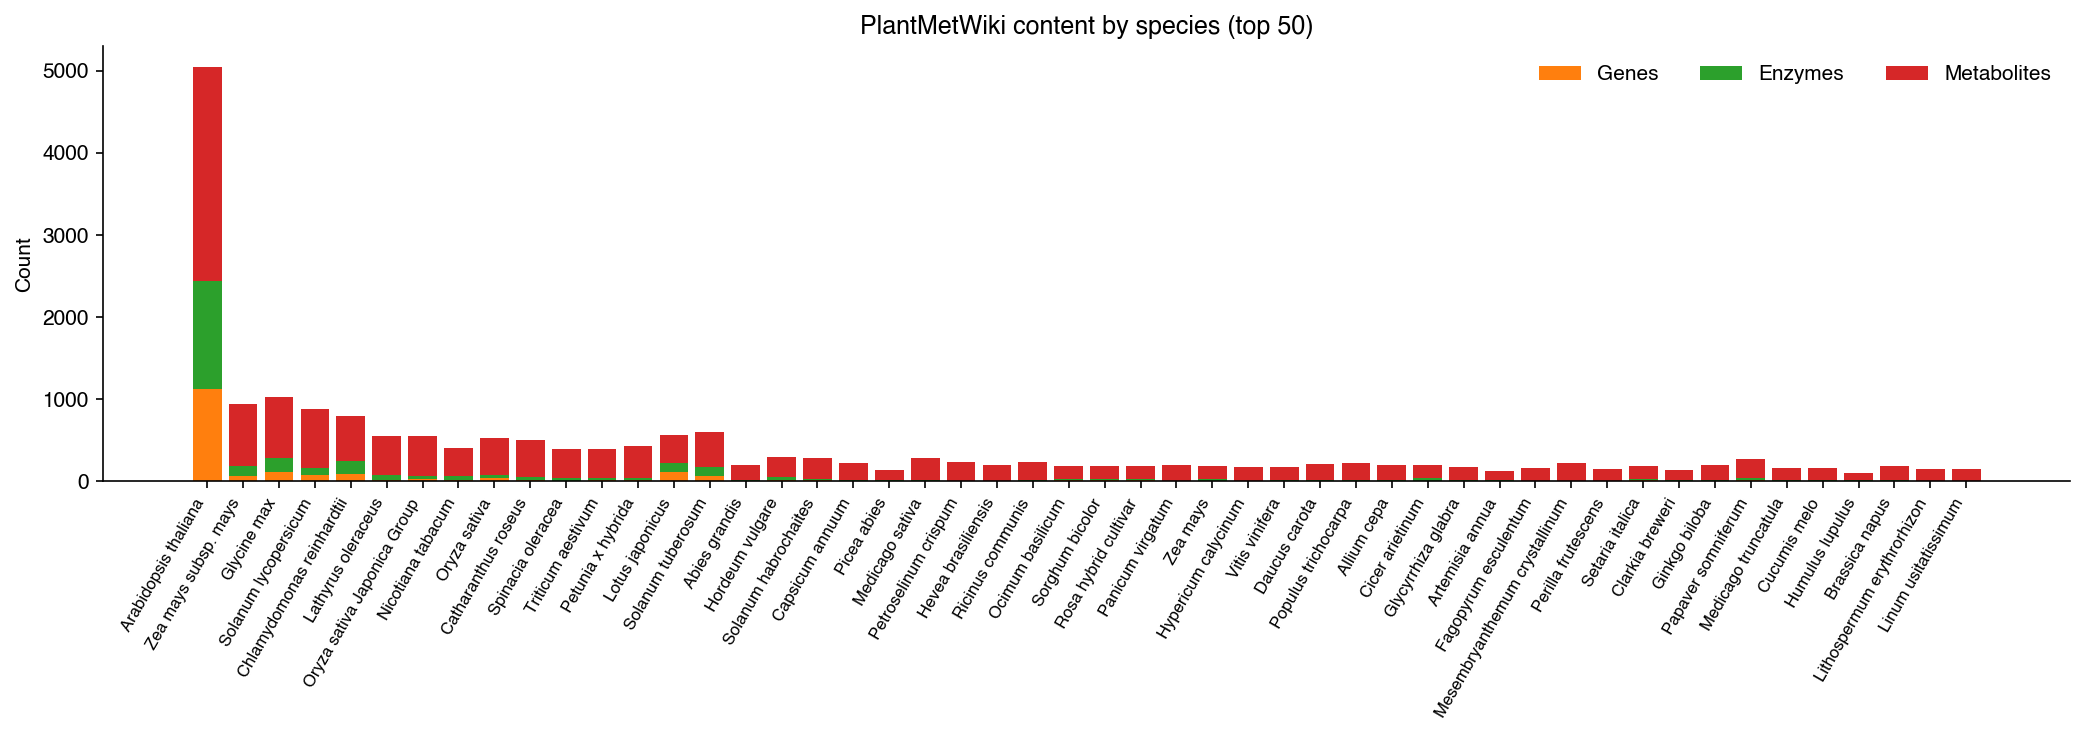

In [7]:
top50 = per_species.sort_values("pathways", ascending=False).head(50).copy()
stack_metrics = [c for c in ["genes","enzymes","metabolites"] if c in top50.columns]
COLORS = {"genes": "C1", "enzymes": "C2", "metabolites": "C3"}

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(top50))
bottom = np.zeros(len(top50))
for m in stack_metrics:
    ax.bar(x, top50[m].values, bottom=bottom, label=m.capitalize(), color=COLORS[m])
    bottom += top50[m].values
ax.set_xticks(x)
ax.set_xticklabels(top50["species"], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title("PlantMetWiki content by species (top 50)")
ax.legend(ncol=3, frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save_fig(fig, "plantmetwiki_species_metrics_stacked_top50")
plt.show()

### Interpretation

Each bar shows the number of directly annotated **GeneProduct** (orange) and **Protein/enzyme** (green) nodes for the top 50 species by pathway count.

*Arabidopsis thaliana* dominates by a large margin because PlantCyc's reference database (AraCyc) is the most completely curated plant pathway collection.
The sharp drop after the top 5–10 species reflects the uneven curation depth across the PlantCyc species databases.

**Important caveat:** this figure shows *only* entities with a direct `wp:organism` triple.
Genes and proteins that lack a resolvable species annotation (~4 % and ~1 %, respectively; see Figure 3b) are excluded from these bars.
See Figure 6b for the extended view that adds metabolites, conversions, and publications via indirect pathway co-occurrence.


> **Figure caption — Species metrics, direct annotations (top 50).**
> Stacked bar chart for the 50 species with the most pathways, showing directly annotated entity counts per species.
> Species identity is encoded as `wp:organism ncbi:XXXXXX` (WikiPathways predicate, NCBITaxon IRI).
> Orange bars: `wp:GeneProduct` nodes tagged with a specific species (excluding the Viridiplantae root `ncbi:33090`).
> Green bars: `wp:Protein` (enzyme) nodes with a species tag.
> Species are ordered from left to right by decreasing pathway count (via `dcterms:isPartOf ?pw . ?pw a wp:Pathway`).


---
## 6b. Figure: Extended species metrics — indirect via shared pathway

Genes/enzymes are **directly** annotated with `wp:organism` in the taxonomy-extra graph.
Metabolites, conversions, and publications have **no direct species tag** — they are
attributed *indirectly* via shared pathway: if a gene of species X is in pathway P,
all metabolites, conversions, and publications in P are counted for species X.

  Saved → figures/output/figures/plantmetwiki_species_combined_top50.{pdf,svg}


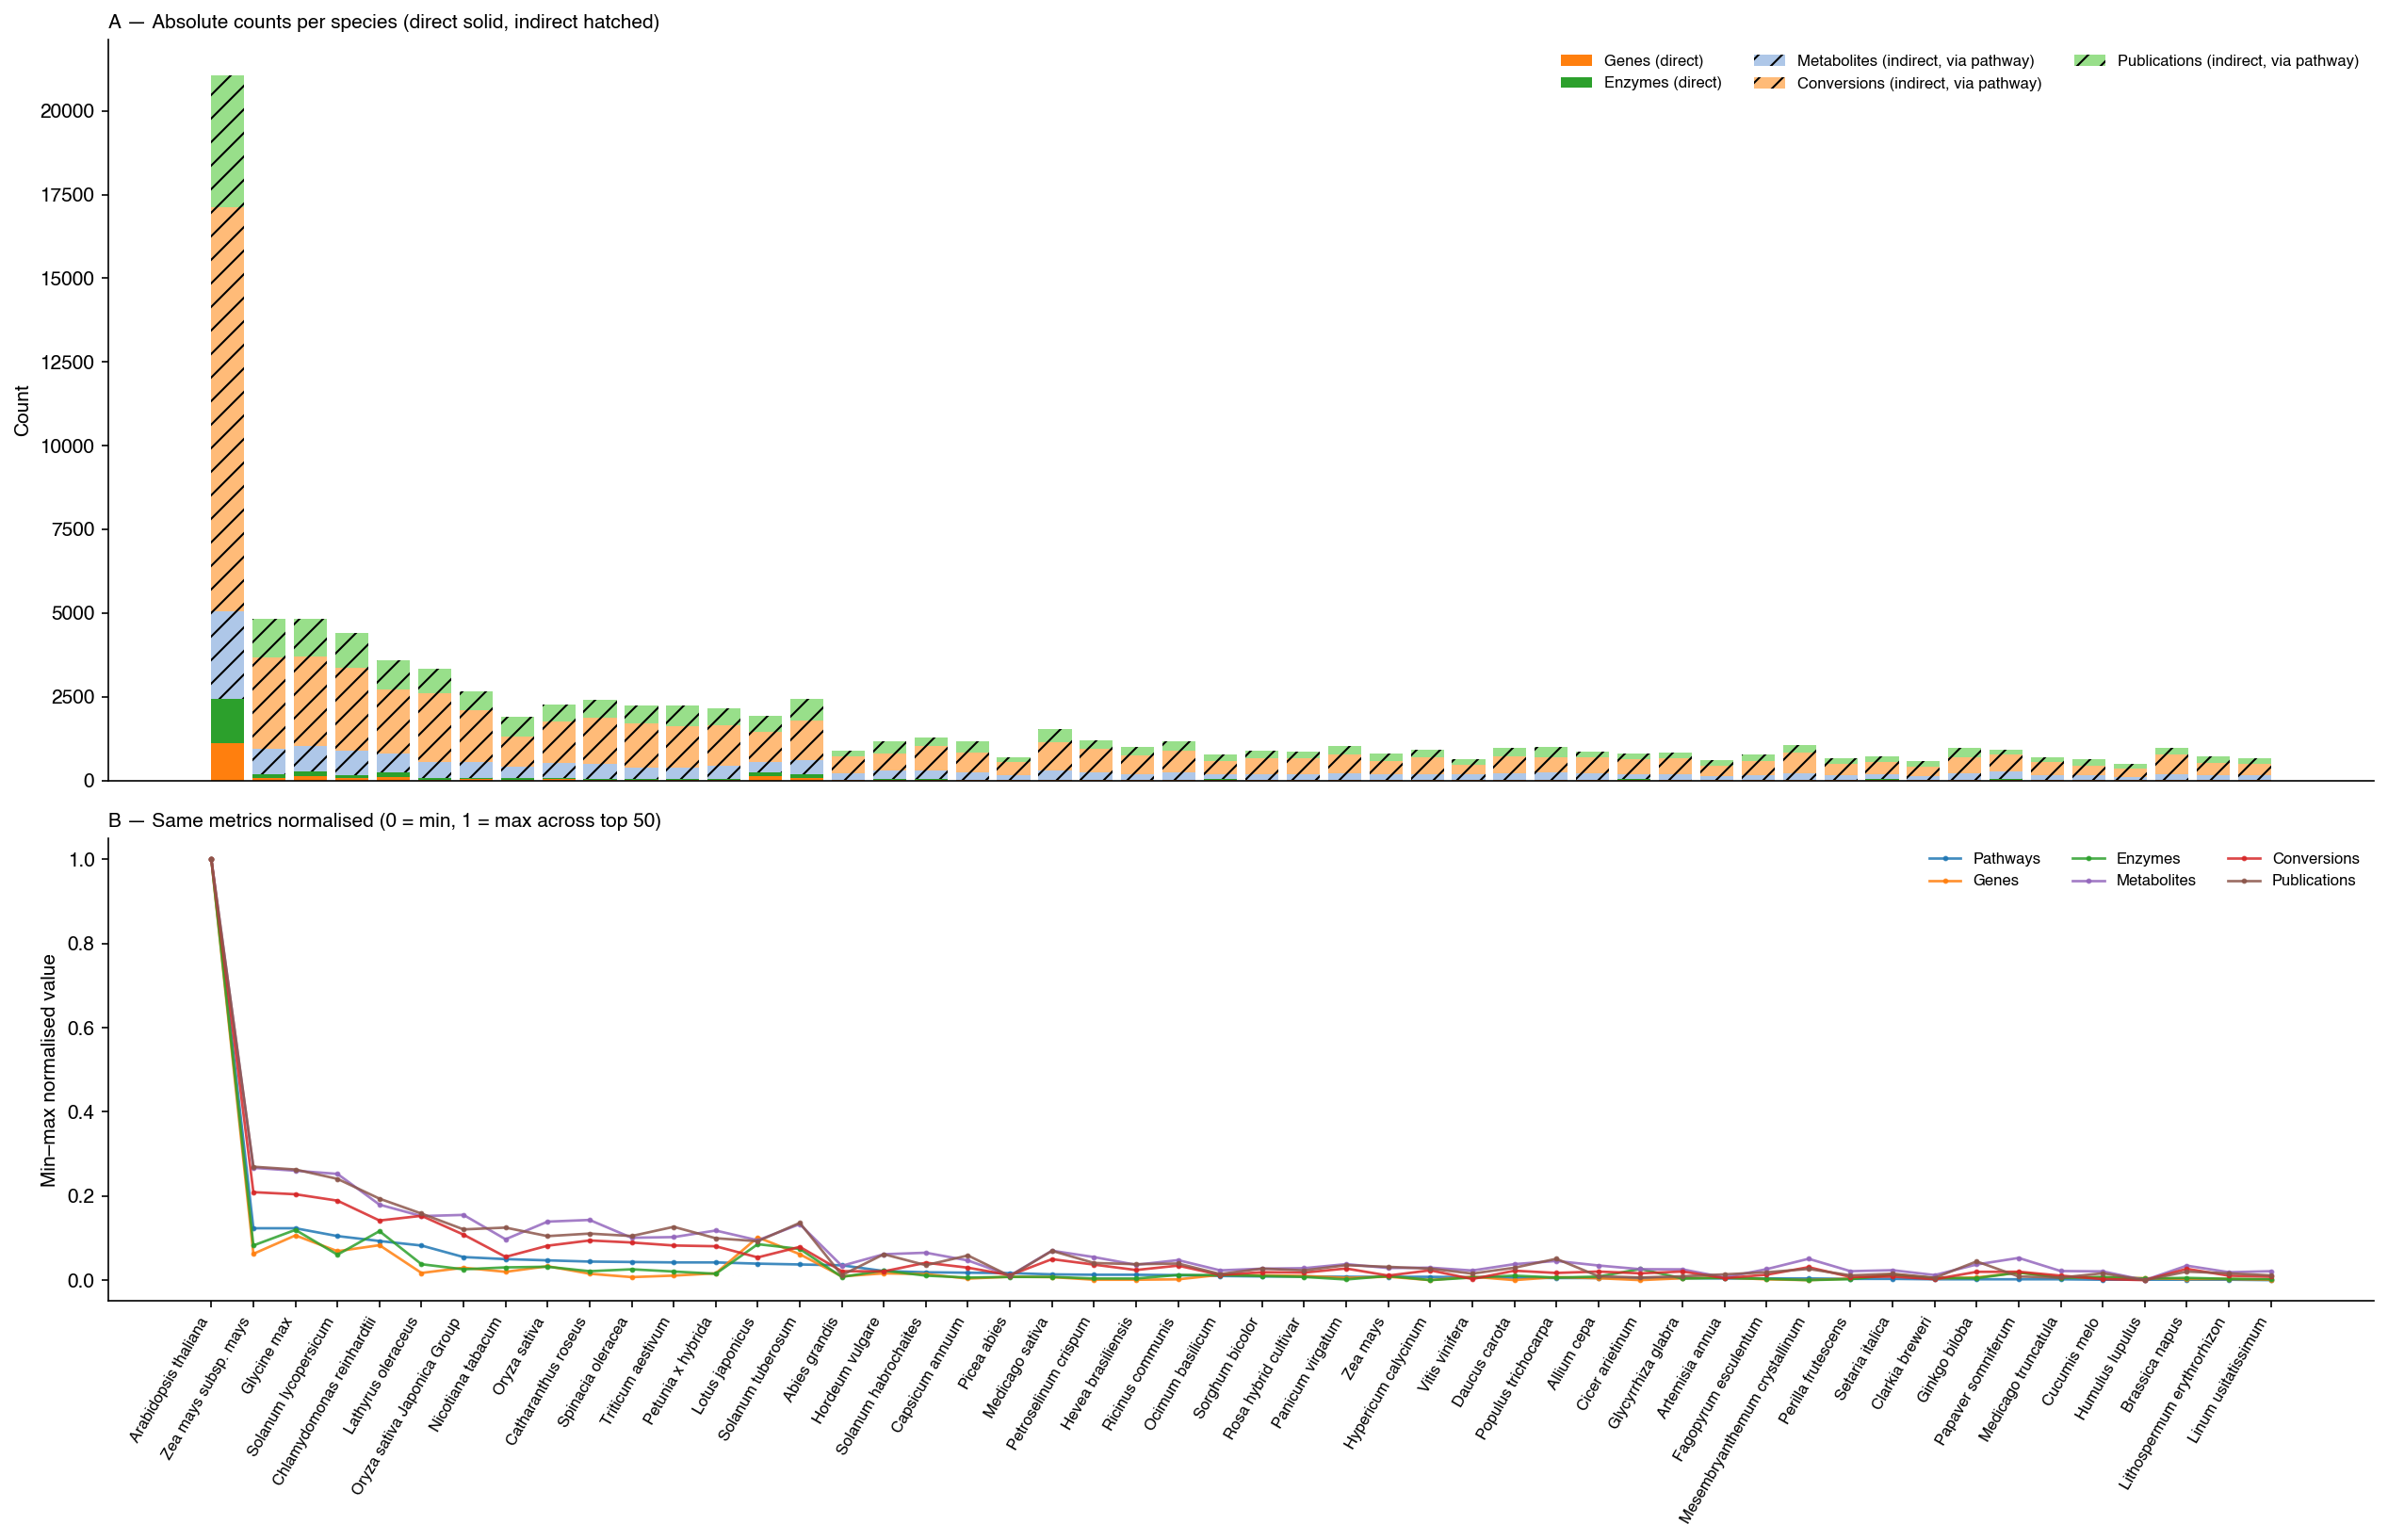

In [8]:
top50_ext = per_species.sort_values('pathways', ascending=False).head(50).copy()
for col in ['pathways', 'genes', 'enzymes', 'metabolites', 'conversions', 'publications']:
    if col in top50_ext.columns:
        top50_ext[col] = pd.to_numeric(top50_ext[col], errors='coerce').fillna(0).astype(int)

direct_metrics   = [c for c in ['genes', 'enzymes'] if c in top50_ext.columns]
indirect_metrics = [c for c in ['metabolites', 'conversions', 'publications'] if c in top50_ext.columns]
all_metrics      = [c for c in ['pathways', 'genes', 'enzymes', 'metabolites', 'conversions', 'publications']
                    if c in top50_ext.columns]

COLORS_D  = {'genes': 'C1', 'enzymes': 'C2'}
COLORS_I  = {'metabolites': '#aec7e8', 'conversions': '#ffbb78', 'publications': '#98df8a'}
LINE_COLS = {'pathways': '#1f77b4', 'genes': '#ff7f0e', 'enzymes': '#2ca02c',
             'metabolites': '#9467bd', 'conversions': '#d62728', 'publications': '#8c564b'}

x = np.arange(len(top50_ext))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 11),
                                gridspec_kw={'height_ratios': [1.6, 1]},
                                sharex=False)
fig.subplots_adjust(hspace=0.08)

# ── Panel A: stacked bar ──────────────────────────────────────────────────────
bottom = np.zeros(len(top50_ext))
for m in direct_metrics:
    ax1.bar(x, top50_ext[m].values, bottom=bottom,
            label=f'{m.capitalize()} (direct)', color=COLORS_D[m])
    bottom += top50_ext[m].values
for m in indirect_metrics:
    ax1.bar(x, top50_ext[m].values, bottom=bottom,
            label=f'{m.capitalize()} (indirect, via pathway)', color=COLORS_I[m], hatch='//')
    bottom += top50_ext[m].values

ax1.set_xticks([])
ax1.set_ylabel('Count')
ax1.set_title('A — Absolute counts per species (direct solid, indirect hatched)', loc='left', fontsize=10)
ax1.legend(ncol=3, frameon=False, fontsize=8, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel B: min-max normalised line plot ─────────────────────────────────────
for m in all_metrics:
    vals = top50_ext[m].values.astype(float)
    mn, mx = vals.min(), vals.max()
    norm_vals = (vals - mn) / (mx - mn) if mx > mn else np.zeros_like(vals)
    ax2.plot(x, norm_vals, label=m.capitalize(),
             color=LINE_COLS.get(m, None), linewidth=1.3,
             marker='.', markersize=3.5, alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(top50_ext['species'], rotation=60, ha='right', fontsize=8)
ax2.set_ylabel('Min–max normalised value')
ax2.set_title('B — Same metrics normalised (0 = min, 1 = max across top 50)', loc='left', fontsize=10)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(ncol=3, frameon=False, fontsize=8, loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_fig(fig, 'plantmetwiki_species_combined_top50')
plt.show()


### Interpretation

The **solid segments** (genes, enzymes) are the same directly annotated counts as Figure 6.

The **hatched segments** add entities attributed *indirectly*: if at least one gene of species X appears in pathway P, then every metabolite, conversion (reaction step), and citable publication referenced by pathway P is attributed to species X.

This indirect attribution reflects the biological reality that a pathway's metabolites and reaction steps are Arabidopsis-relevant *because* Arabidopsis has the enzymes to catalyse them — not because the metabolites themselves carry a species tag.

For *Arabidopsis thaliana* (1,038 pathways), the indirect layer adds:
- 2,597 metabolites
- 12,092 conversions
- 3,929 publications

on top of the 1,121 directly annotated genes and 1,325 enzymes.

Note that indirect counts are *not* unique: a metabolite that appears in 50 Arabidopsis-annotated pathways is counted 50 times. The hatched bars therefore measure *coverage breadth* (how much biochemistry is connected to a species), not *unique entity count*.


> **Figure caption — Species metrics, extended (top 50).**
> Two-panel comparison for the 50 most pathway-rich species.
> **(A)** Absolute counts. Solid bars: entities with a direct `wp:organism` annotation (`wp:GeneProduct`, `wp:Protein`).
> Hatched bars: entities attributed *indirectly* via shared-pathway co-occurrence — if a `wp:GeneProduct` of species `ncbi:X` is in pathway P (`dcterms:isPartOf`), all `wp:Metabolite` and `wp:Conversion` nodes in P are attributed to species X.
> Publications are pathway-level `dcterms:references` / `cito:cites` links aggregated the same way.
> **(B)** Min–max normalisation (0 = minimum, 1 = maximum across the top 50 species) of the same six metrics: pathways, genes (`wp:GeneProduct`), enzymes (`wp:Protein`), metabolites (`wp:Metabolite`), conversions (`wp:Conversion`), and publications.
> Normalisation reveals cross-species patterns independent of the large absolute differences driven by *Arabidopsis thaliana* (NCBITaxon\_3702).


---
## 7. Figure: Scatter — genes vs metabolites (sized by species count)

  Saved → figures/output/figures/scatter_genes_vs_metabolites_size_species.{pdf,svg}
Saved top_pathways_by_genes.csv


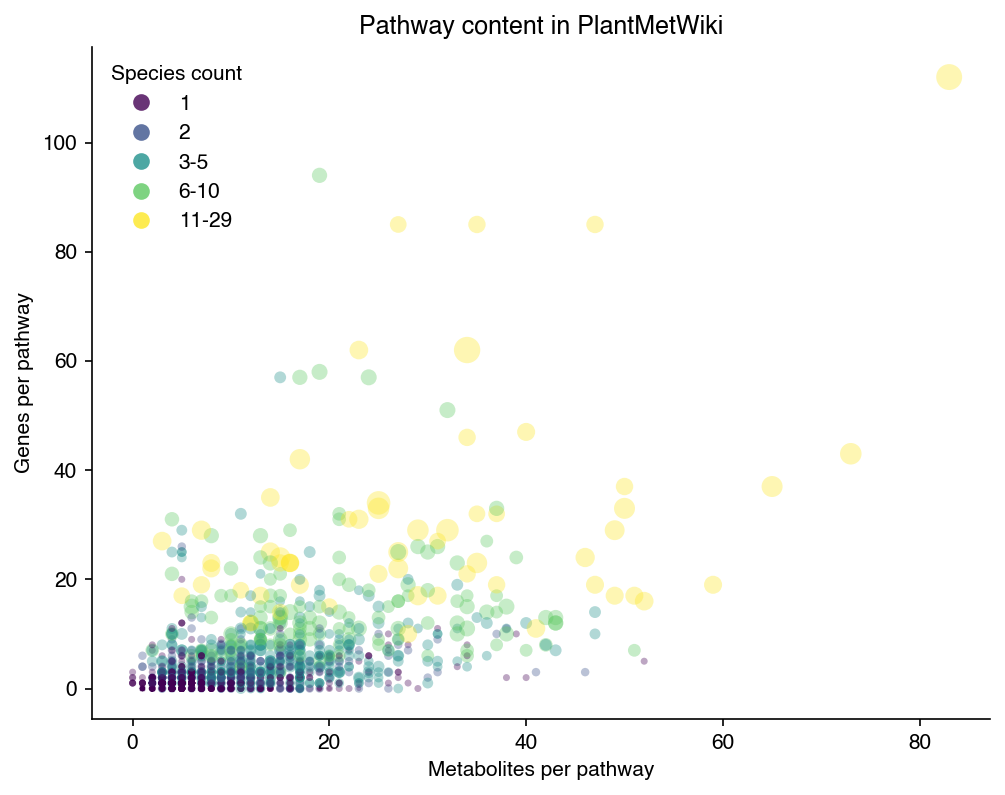

In [9]:
merged = metabolites[['pwID','metabolites']].merge(
    genes[['pwID','genes']], on='pwID', how='outer'
).merge(
    species_pw[['pwID','species']], on='pwID', how='outer'
).fillna(0)
merged = merged.merge(titles.rename(columns={'pwID':'pwID','title':'title'}),
                      on='pwID', how='left')
merged = merged[(merged['metabolites'] > 0) | (merged['genes'] > 0)].copy()
# Ensure species is numeric with no NaN
merged['species'] = pd.to_numeric(merged['species'], errors='coerce').fillna(0)

sp_min = int(merged['species'].min())
sp_max = int(merged['species'].max())
size = 6 + (merged['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

bins   = sorted(set([0, 1, 2, 5, 10, max(10, sp_max)]))
blabels = [f"{bins[i-1]+1 if i>1 else 0}-{bins[i]}" if bins[i-1]+1 != bins[i]
           else str(bins[i]) for i in range(1, len(bins))]
merged['sp_bin']  = pd.cut(merged['species'], bins=bins, include_lowest=True,
                            right=True, labels=blabels)
merged['sp_code'] = merged['sp_bin'].cat.codes

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.scatter(merged['metabolites'], merged['genes'],
           s=size, c=merged['sp_code'], cmap='viridis',
           alpha=0.35, edgecolors='none')
ax.set_xlabel('Metabolites per pathway')
ax.set_ylabel('Genes per pathway')
ax.set_title('Pathway content in PlantMetWiki')

cmap = plt.get_cmap('viridis')
norm_c = mpl.colors.Normalize(vmin=0, vmax=max(1, len(blabels)-1))
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=cmap(norm_c(i)), markeredgecolor='none',
                  markersize=8, alpha=0.8) for i in range(len(blabels))]
ax.legend(handles, blabels, title='Species count', loc='best', frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'scatter_genes_vs_metabolites_size_species')

merged.sort_values(['genes','metabolites'], ascending=False)[
    ['pwID','title','genes','metabolites','species']
].head(50).to_csv(OUT_DIR / 'top_pathways_by_genes.csv', index=False)
print('Saved top_pathways_by_genes.csv')
plt.show()

### Interpretation

Each dot is one pathway or reaction object (2,478 total after outer-joining metabolites and genes).
**X-axis:** number of distinct metabolite nodes in that pathway.
**Y-axis:** number of distinct gene-product nodes.
**Dot size and colour (viridis):** number of annotated species — large/bright = multispecies pathway, small/dark = single-species or unannotated.

Most pathways cluster near the origin (few genes, few metabolites), representing individual enzymatic reactions (RC\* objects) or narrowly defined single-step pathways.
The sparse cloud toward the top-right contains large multispecies superpathways and central metabolic maps that are extensively curated across many species.

Pathways far to the right (many metabolites, few genes) tend to be compound-rich maps where metabolite nodes have been drawn but enzyme genes were not annotated.
Pathways far upward (many genes, few metabolites) often represent signalling or regulatory modules.


> **Figure caption — Pathway content scatter plot.**
> Each point is one `wp:Pathway` object (PC\* or RC\* IRI, 2,478 total).
> X-axis: count of distinct `wp:Metabolite` nodes (`dcterms:isPartOf` that pathway).
> Y-axis: count of distinct `wp:GeneProduct` nodes.
> Dot size and colour (viridis scale): number of distinct `wp:organism` taxon annotations (`ncbi:*`, excluding root `ncbi:33090`) pointing to nodes in that pathway.
> Large/bright = multispecies; small/dark = single-species or unannotated.


---
## 7b. Figure: Scatter with pathway labels for outliers

Labels the 15 most 'outlying' pathways — those furthest from the origin
(largest Euclidean distance from the point cloud centroid in genes–metabolites space).

  Saved → figures/output/figures/scatter_outlying_pathways_labelled.{pdf,svg}


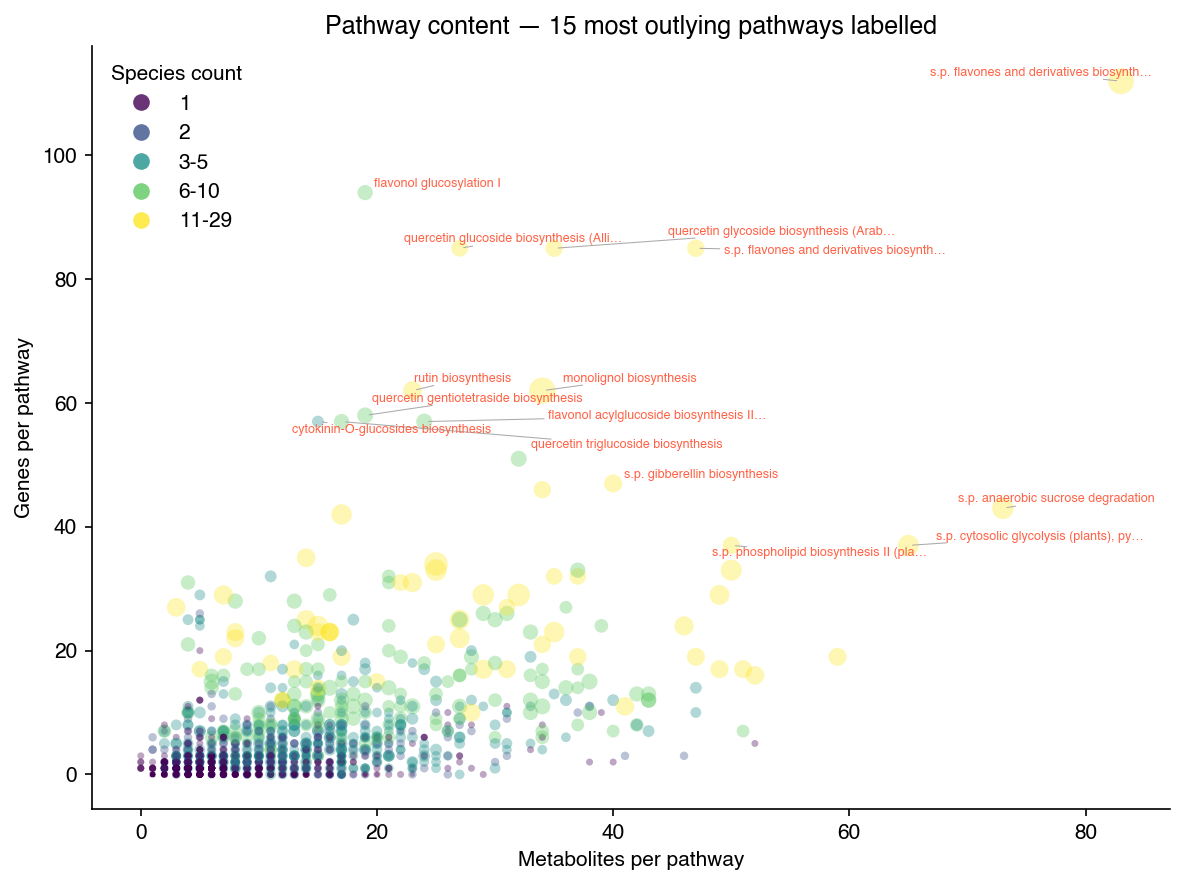

In [10]:
from adjustText import adjust_text

# Reuse merged from Figure 7 (rebuild if needed)
if 'merged' not in dir() or '_dist' not in merged.columns:
    merged = metabolites[['pwID','metabolites']].merge(
        genes[['pwID','genes']], on='pwID', how='outer'
    ).merge(species_pw[['pwID','species']], on='pwID', how='outer').fillna(0)
    merged = merged.merge(titles, on='pwID', how='left')
    merged = merged[(merged['metabolites'] > 0) | (merged['genes'] > 0)].copy()
    merged['species'] = pd.to_numeric(merged['species'], errors='coerce').fillna(0)

# Outlier score: Euclidean distance from centroid
cx, cy = merged['metabolites'].mean(), merged['genes'].mean()
merged['_dist'] = np.sqrt((merged['metabolites'] - cx)**2 + (merged['genes'] - cy)**2)
outliers = merged.nlargest(15, '_dist')

# ── Same size / colour encoding as Figure 7 ──────────────────────────────────
sp_min = int(merged['species'].min())
sp_max = int(merged['species'].max())
size   = 6 + (merged['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

bins    = sorted(set([0, 1, 2, 5, 10, max(10, sp_max)]))
blabels = [f"{bins[i-1]+1 if i>1 else 0}-{bins[i]}" if bins[i-1]+1 != bins[i]
           else str(bins[i]) for i in range(1, len(bins))]
merged['sp_bin']  = pd.cut(merged['species'], bins=bins, include_lowest=True,
                            right=True, labels=blabels)
merged['sp_code'] = merged['sp_bin'].cat.codes

out_size = 6 + (outliers['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

fig, ax = plt.subplots(figsize=(8, 6))

# All pathways — viridis by species count
ax.scatter(merged['metabolites'], merged['genes'],
           s=size, c=merged['sp_code'], cmap='viridis',
           alpha=0.35, edgecolors='none')

# Labels with adjustText
texts = []
for _, row in outliers.iterrows():
    label = str(row.get('title', row['pwID'])).replace('superpathway of ', 's.p. ')
    if len(label) > 40:
        label = label[:38] + '\u2026'
    texts.append(ax.text(row['metabolites'], row['genes'], label,
                         fontsize=6, color='tomato'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.5))

# Species-count legend (same as Figure 7) + outlier entry
cmap   = plt.get_cmap('viridis')
norm_c = mpl.colors.Normalize(vmin=0, vmax=max(1, len(blabels)-1))
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=cmap(norm_c(i)), markeredgecolor='none',
                  markersize=8, alpha=0.8) for i in range(len(blabels))]
ax.legend(handles, blabels, title='Species count', loc='best', frameon=False)

ax.set_xlabel('Metabolites per pathway')
ax.set_ylabel('Genes per pathway')
ax.set_title('Pathway content — 15 most outlying pathways labelled')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'scatter_outlying_pathways_labelled')
plt.show()


### Interpretation

The 15 red-ringed pathways are the furthest from the centroid of the point cloud (Euclidean distance in genes–metabolites space) and therefore represent the most atypical content in PlantMetWiki.

They fall into two characteristic groups:

1. **Large superpathways** (top-right quadrant): contain many genes *and* many metabolites, typically because they aggregate several sub-pathways. These are the most information-dense objects in the resource.
2. **Compound-rich maps** (far right, few genes): metabolite nodes were imported from PlantCyc pathway diagrams but enzyme genes were not annotated — indicating gaps in the gene-to-reaction linkage.

Because these pathways pull in the most metabolites (and hence the most indirect species attributions via Figure 6b), they disproportionately shape species-level statistics.
Reviewers inspecting any single-species enrichment result should check whether the signal comes from one of these pathway giants.


> **Figure caption — Pathway content scatter plot with labelled outliers.**
> Same data and encoding as the scatter plot above.
> Red rings and labels mark the 15 `wp:Pathway` objects furthest from the point-cloud centroid (Euclidean distance in `wp:Metabolite` × `wp:GeneProduct` space).
> These outliers include large superpathways (aggregating many sub-pathways via `dcterms:isPartOf`) and compound-rich maps where `wp:Metabolite` nodes were imported without corresponding `wp:GeneProduct` annotations.


---
## Sandbox